In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
dx = 0.05
dt = 0.0012
t_max = 0.06
x_max = 1.0

In [4]:
Nx = int(x_max / dx) + 1
Nt = int(t_max / dt) + 1

In [5]:
x = np.linspace(0, x_max, Nx)
t = np.linspace(0, t_max, Nt)

# u(t, x)
u = np.zeros((Nt, Nx))

In [6]:
for i in range(Nx):
    if x[i] <= 0.5:
        u[0, i] = 2 * x[i]
    else:
        u[0, i] = 2 - 2 * x[i]

In [7]:
for k in range(0, Nt - 1):
    for i in range(1, Nx - 1):
        u[k+1, i] = u[k, i] + (dt / (dx**2)) * (u[k, i+1] - 2*u[k, i] + u[k, i-1])

In [8]:
time_indices = np.arange(0, Nt, 10)

X, T = np.meshgrid(x, t[time_indices])
U = u[time_indices, :]

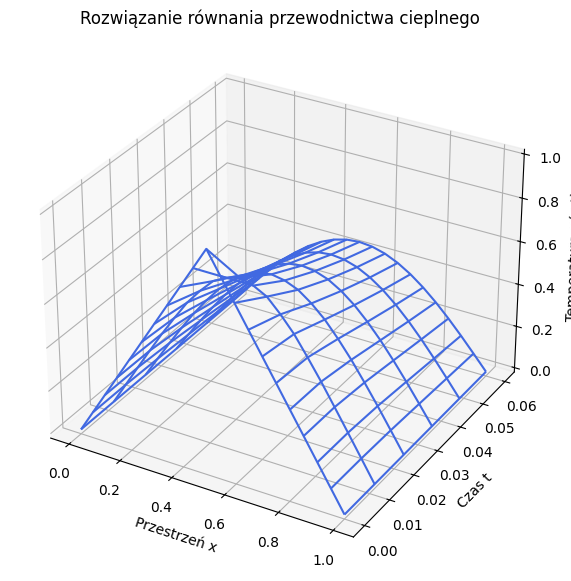

In [9]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, T, U, color='royalblue')

ax.set_xlabel('Przestrzeń x')
ax.set_ylabel('Czas t')
ax.set_zlabel('Temperatura u(x,t)')
ax.set_title('Rozwiązanie równania przewodnictwa cieplnego')
plt.show()

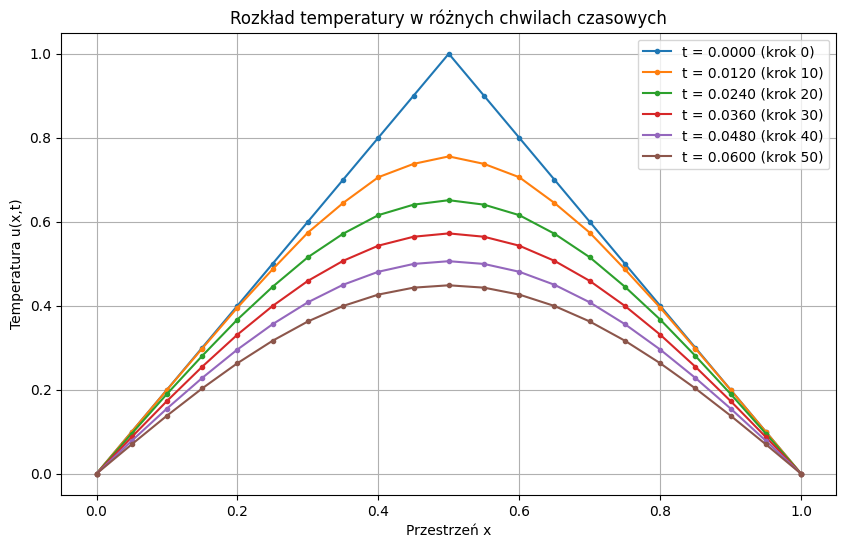

In [10]:
plt.figure(figsize=(10, 6))
for idx in time_indices:
    plt.plot(x, u[idx, :], label=f't = {t[idx]:.4f} (krok {idx})', marker='o', markersize=3)

plt.xlabel('Przestrzeń x')
plt.ylabel('Temperatura u(x,t)')
plt.title('Rozkład temperatury w różnych chwilach czasowych')
plt.legend()
plt.grid(True)
plt.show()